# ex017_Xie2015_B4

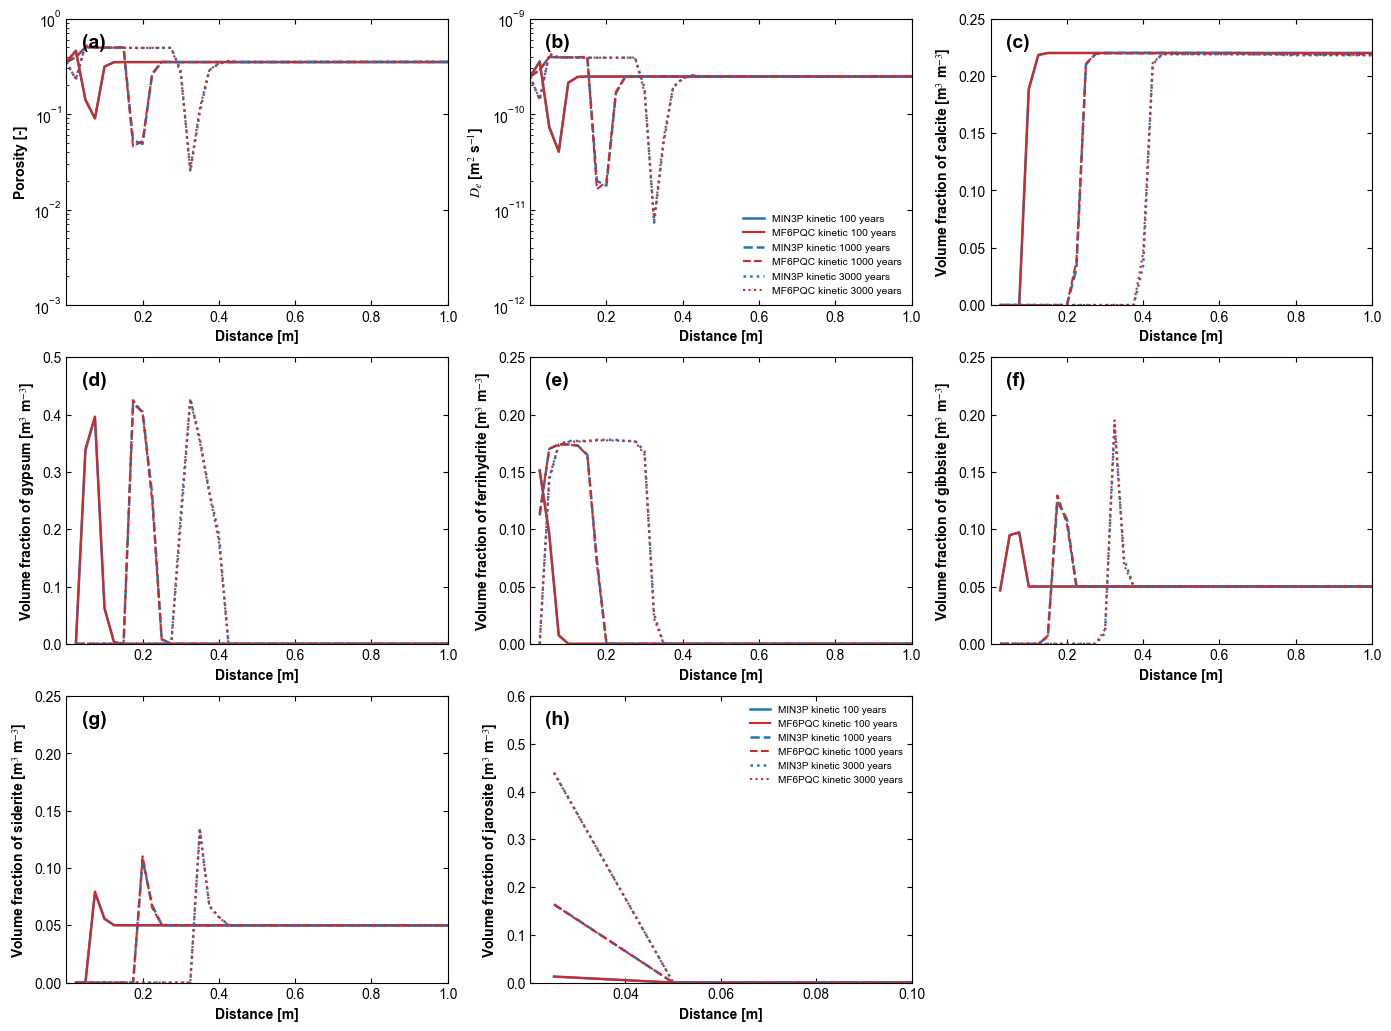

In [1]:
from run import MINERAL_MOLAR_VOLUMES

import pandas as pd
from IPython.display import display

comparison_rows = []
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"
import flopy
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "mathtext.fontset": "stix",
    }
)
PROFILE_YEARS = (100, 1000, 3000)
LENGTH = 2.0
SECONDS_PER_DAY = 86400.0
results = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
result_times = np.load(OUTPUT_DIR / "results_times.npy")
porosity = np.load(OUTPUT_DIR / "results_porosity.npy")
pore_diffusion = np.load(OUTPUT_DIR / "results_diffc.npy")
reference_hydro = pd.read_csv(INPUT_DIR / "MIN3P_results.csv")
reference_minerals = (
    pd.read_csv(INPUT_DIR / "MIN3P_minerals.csv").dropna(how="all").reset_index(drop=True)
)
sim = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), sim_name="model", verbosity_level=0)
gwf = sim.get_model("gwf_model")
delr = gwf.disu.area.array.ravel() if gwf.disu is not None else gwf.dis.delr.array.ravel()
x_mf6 = np.linspace(0.0, LENGTH, len(delr))
x_reference_hydro = np.linspace(0.0, LENGTH, len(reference_hydro))
dx = float(delr[1])
x_reference_minerals = dx * np.arange(1, len(reference_minerals) + 1)
state_years = result_times / 365.0
completed_years = state_years[1:]


def state_index(year):
    index = int(np.abs(state_years - year).argmin())
    return index


def diffusion_index(year):
    index = int(np.abs(completed_years - year).argmin())
    return index


def mineral_profile(year, mineral):
    moles_per_litre_bulk = results[state_index(year), headings.index(mineral)]
    return moles_per_litre_bulk * MINERAL_MOLAR_VOLUMES[mineral]


def effective_diffusion(year):
    return porosity[state_index(year)] * pore_diffusion[diffusion_index(year)] / SECONDS_PER_DAY


styles = {100: "-", 1000: "--", 3000: ":"}
reference_color = "tab:blue"
model_color = "tab:red"
legend_handles = [
    item
    for year, style in styles.items()
    for item in (
        Line2D(
            [], [], color=reference_color, ls=style, lw=1.8, label=f"MIN3P kinetic {year} years"
        ),
        Line2D([], [], color=model_color, ls=style, lw=1.5, label=f"MF6PQC kinetic {year} years"),
    )
]
for year in PROFILE_YEARS:
    for name, values in [
        ("Porosity", porosity[state_index(year)]),
        ("Diffusion coefficient", effective_diffusion(year)),
    ]:
        error = np.interp(x_reference_hydro, x_mf6, values) - reference_hydro[f"{name} {year}years"]
        comparison_rows.append(
            {
                "Variable": name,
                "Time (yr)": year,
                "RMSE": np.sqrt(np.mean(error**2)),
                "Max abs": np.max(np.abs(error)),
            }
        )
    for mineral in MINERAL_MOLAR_VOLUMES:
        error = (
            np.interp(x_reference_minerals, x_mf6[1:-1], mineral_profile(year, mineral)[1:-1])
            - reference_minerals[f"{mineral} {year}years"]
        )
        comparison_rows.append(
            {
                "Variable": mineral,
                "Time (yr)": year,
                "RMSE": np.sqrt(np.mean(error**2)),
                "Max abs": np.max(np.abs(error)),
            }
        )
fig, combined_axes = plt.subplots(3, 3, figsize=(13.8, 10.2), constrained_layout=True)
axes = combined_axes.flat[:2]
for year, style in styles.items():
    axes[0].plot(
        x_reference_hydro,
        reference_hydro[f"Porosity {year}years"],
        color=reference_color,
        ls=style,
        lw=1.8,
    )
    axes[0].plot(x_mf6, porosity[state_index(year)], color=model_color, ls=style, lw=1.5)
    axes[1].plot(
        x_reference_hydro,
        reference_hydro[f"Diffusion coefficient {year}years"],
        color=reference_color,
        ls=style,
        lw=1.8,
    )
    axes[1].plot(x_mf6, effective_diffusion(year), color=model_color, ls=style, lw=1.5)
axes[0].set(xlim=(0.0, 1.0), ylim=(0.001, 1.0), xlabel="Distance [m]", ylabel="Porosity [-]")
axes[1].set(
    xlim=(0.0, 1.0), ylim=(1e-12, 1e-09), xlabel="Distance [m]", ylabel="$D_e$ [m$^2$ s$^{-1}$]"
)
for ax, label in zip(axes, ("(a)", "(b)"), strict=False):
    ax.set_yscale("log")
    ax.set_xticks(np.arange(0.2, 1.01, 0.2))
    ax.text(0.04, 0.95, label, transform=ax.transAxes, va="top", fontsize=14, fontweight="bold")
    ax.tick_params(top=True, right=True)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
axes[1].legend(handles=legend_handles, frameon=False, fontsize=7.5, loc="lower right")
mineral_panels = [
    ("Calcite", (0.0, 0.25), (0.0, 1.0)),
    ("Gypsum", (0.0, 0.5), (0.0, 1.0)),
    ("Ferrihydrite", (0.0, 0.25), (0.0, 1.0)),
    ("Gibbsite", (0.0, 0.25), (0.0, 1.0)),
    ("Siderite", (0.0, 0.25), (0.0, 1.0)),
    ("Jarosite", (0.0, 0.6), (0.02, 0.1)),
]
axes = np.array(combined_axes.flat[2:8]).reshape(3, 2)
for ax, (mineral, ylim, xlim), label in zip(
    axes.flat, mineral_panels, ("(c)", "(d)", "(e)", "(f)", "(g)", "(h)"), strict=False
):
    for year, style in styles.items():
        ax.plot(
            x_reference_minerals,
            reference_minerals[f"{mineral} {year}years"],
            color=reference_color,
            ls=style,
            lw=1.8,
        )
        ax.plot(
            x_mf6[1:-1], mineral_profile(year, mineral)[1:-1], color=model_color, ls=style, lw=1.5
        )
    ax.set(
        xlim=xlim,
        ylim=ylim,
        xlabel="Distance [m]",
        ylabel=f"Volume fraction of {mineral.lower()} [m$^3$ m$^{{-3}}$]",
    )
    ax.text(0.04, 0.95, label, transform=ax.transAxes, va="top", fontsize=14, fontweight="bold")
    ax.tick_params(top=True, right=True)
    if mineral == "Jarosite":
        ax.set_xticks(np.arange(0.04, 0.101, 0.02))
    else:
        ax.set_xticks(np.arange(0.2, 1.01, 0.2))
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
axes[2, 1].legend(handles=legend_handles, frameon=False, fontsize=7.2, loc="upper right")
for ax in combined_axes.flat[8:]:
    ax.set_axis_off()
fig.savefig(OUTPUT_DIR / "comparison.png", dpi=180, bbox_inches="tight")
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.pivot(
    index="Variable", columns="Time (yr)", values=["RMSE", "Max abs"]
).reindex(comparison["Variable"].drop_duplicates())
display(
    comparison.style.format("{:.6g}").format_index("{:.6g}", axis=1, level=1).set_uuid("ex017_1")
)

C:\ProgramFiles\Miniconda\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


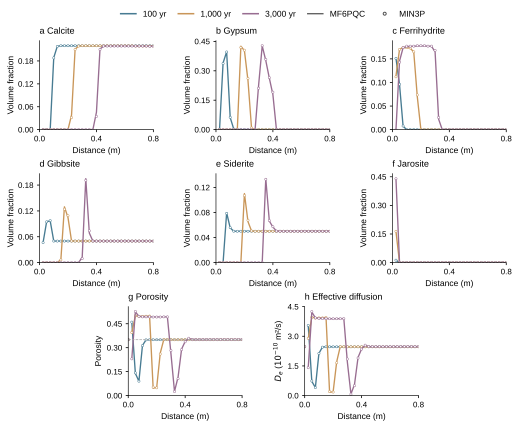

In [2]:
%config InlineBackend.figure_format = 'svg'
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

W = 183 / 25.4
COL = ["#477B92", "#C99659", "#986D91"]
mpl.rcdefaults()
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.facecolor": "white",
    }
)
raw = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
result_times = np.load(OUTPUT_DIR / "results_times.npy")
mineral_order = ["Calcite", "Gypsum", "Ferrihydrite", "Gibbsite", "Siderite", "Jarosite"]
D = {
    "reference_x_m": np.linspace(0, 2, len(reference_hydro)),
    "reference_mineral_x_m": np.linspace(0.025, 1.975, len(reference_minerals)),
    "reference_phi": np.array(
        [reference_hydro[f"Porosity {t}years"].to_numpy() for t in PROFILE_YEARS]
    ),
    "reference_De_m2_s": np.array(
        [reference_hydro[f"Diffusion coefficient {t}years"].to_numpy() for t in PROFILE_YEARS]
    ),
    "reference_minerals": np.array(
        [
            [reference_minerals[f"{m} {t}years"].to_numpy() for m in mineral_order]
            for t in PROFILE_YEARS
        ]
    ),
}
model = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), verbosity_level=0)
flow_model = model.get_model("gwf_model")
dx = (
    flow_model.disu.area.array.ravel()
    if flow_model.disu is not None
    else flow_model.dis.delr.array.ravel()
)
D["x_m"] = np.asarray(flow_model.modelgrid.xcellcenters).ravel()
D["phi"] = np.load(OUTPUT_DIR / "results_porosity.npy")
D["K_m_d"] = np.load(OUTPUT_DIR / "results_K.npy")
D["time_yr"] = result_times / 365.0
D["mineral_names"] = np.array(
    ["Calcite", "Gypsum", "Ferrihydrite", "Gibbsite", "Siderite", "Jarosite"]
)
D["molar_volumes_L_mol"] = np.array([MINERAL_MOLAR_VOLUMES[name] for name in D["mineral_names"]])
D["minerals"] = np.stack(
    [
        raw[:, headings.index(n)] * v
        for n, v in zip(D["mineral_names"], D["molar_volumes_L_mol"], strict=False)
    ],
    axis=1,
)
D["selected_yr"] = np.array([100, 1000, 3000])
completed = np.load(OUTPUT_DIR / "results_diffc.npy") / 86400
D["Dp_m2_s"] = np.vstack([np.full(len(dx), 1e-09 * 0.35 ** (1 / 3)), completed])
D["De_m2_s"] = D["phi"] * D["Dp_m2_s"]


def _manuscript_layout_09(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (0, 0),
        (0, -16.5),
        (0, -16.5),
        (0, -16.5),
        (88.747021, -33),
        (88.747021, -33),
    ]
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - 4.5 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def save(n, fig, axes):
    _manuscript_layout_09(fig)
    fig.savefig(OUTPUT_DIR / "comparison_paper.png", dpi=180, bbox_inches="tight")
    plt.show()


def title(ax, letter, name):
    ax.set_title(f"{letter}  {name}", loc="left", pad=7, fontsize=9)


def grid(rows, cols, height, top=0.86, bottom=0.1, wspace=0.5, hspace=0.67):
    fig, axs = plt.subplots(rows, cols, figsize=(W, height), squeeze=False)
    fig.subplots_adjust(left=0.08, right=0.98, top=top, bottom=bottom, wspace=wspace, hspace=hspace)
    return (fig, list(axs.flat))


def legend(fig, times, unit="yr", ref="MIN3P", colors=None):
    colors = colors or (COL if len(times) == 3 else [COL[0], COL[-1]])
    handles = [
        Line2D([], [], color=c, lw=1.5, label=f"{t:,} {unit}")
        for t, c in zip(times, colors, strict=False)
    ]
    handles += [
        Line2D([], [], color=".3", lw=1.2, label="MF6PQC"),
        Line2D([], [], color=".3", ls="none", marker="o", mfc="white", ms=3, label=ref),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.53, 0.991),
        ncol=len(handles),
        columnspacing=1.4,
        handlelength=1.8,
    )


def curves(ax, d, key, refkey, component=None, scale=1, refscale=1, interior=False, xmax=2):
    colors = COL if len(d["selected_yr"]) == 3 else [COL[0], COL[-1]]
    for j, (t, c) in enumerate(zip(d["selected_yr"], colors, strict=False)):
        idx = np.flatnonzero(np.isclose(d["time_yr"], t)).item()
        y = d[key][idx] if component is None else d[key][idx, component]
        cells = slice(1, -1) if interior else slice(None)
        ax.plot(d["x_m"][cells], y[cells] * scale, color=c, lw=1.35)
        rx = d["reference_mineral_x_m"] if refkey == "reference_minerals" else d["reference_x_m"]
        ry = d[refkey][j] if component is None else d[refkey][j, component]
        ax.plot(rx, ry * refscale, ls="none", marker="o", ms=2.3, mfc="white", mec=c, mew=0.5)
    ax.set(
        xlim=(0, xmax), xlabel="Distance (m)", xticks=[0, 0.4, 0.8] if xmax == 0.8 else [0, 1, 2]
    )
    ax.yaxis.set_major_locator(MaxNLocator(4))


def fig9():
    d = D
    fig, allaxes = grid(3, 3, 6.6, top=0.902, bottom=0.084, wspace=0.55, hspace=0.68)
    fig.delaxes(allaxes[-1])
    axs = allaxes[:8]
    legend(fig, [100, 1000, 3000])
    for i, name in enumerate(d["mineral_names"]):
        curves(axs[i], d, "minerals", "reference_minerals", component=i, interior=True, xmax=0.8)
        title(axs[i], chr(97 + i), str(name))
        axs[i].set_ylabel("Volume fraction", labelpad=3)
    curves(axs[6], d, "phi", "reference_phi", interior=True, xmax=0.8)
    title(axs[6], "g", "Porosity")
    axs[6].set_ylabel("Porosity")
    axs[6].axhline(0.35, color=".65", ls="--", lw=0.7)
    curves(
        axs[7],
        d,
        "De_m2_s",
        "reference_De_m2_s",
        scale=10000000000.0,
        refscale=10000000000.0,
        interior=True,
        xmax=0.8,
    )
    title(axs[7], "h", "Effective diffusion")
    axs[7].set_ylabel("$D_e$ ($10^{-10}$ m²/s)")
    for ax in axs:
        vals = np.concatenate(
            [
                line.get_ydata()[(line.get_xdata() >= 0) & (line.get_xdata() <= 0.8)]
                for line in ax.lines
                if len(line.get_xdata()) > 2
            ]
        )
        lo, hi = (float(vals.min()), float(vals.max()))
        margin = (hi - lo) * 0.06
        ax.set_ylim(max(0, lo - margin), hi + margin)
    save(9, fig, axs)


fig9()